# 02 · Exploratory data analysis

All relationships below use the training partition. We investigate which attributes are associated with observed attrition, without asserting that changing an attribute would change an employee's outcome.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
from src.config import FIGURES_DIR, METRICS_DIR, FEATURE_COLUMNS
from src.data.load_data import load_data, split_data
from src.data.explore import exploration_tables
data = load_data()
X_train, X_test, y_train, y_test = split_data(data)

tables = exploration_tables(X_train, y_train)

## Distributions and observed group rates

Inspect every categorical/ordinal predictor with group counts alongside rates. Small groups can have unstable rates; absolute counts alone obscure differences in group size.

,feature,value,count,attrition_rate
0,Education,1,140,0.178571
1,Education,2,224,0.142857
2,Education,3,455,0.186813
3,Education,4,320,0.140625
4,Education,5,37,0.081081
...,...,...,...,...
76,MaritalStatus,Divorced,263,0.110266
77,MaritalStatus,Married,540,0.122222
78,MaritalStatus,Single,373,0.254692
79,OverTime,No,836,0.111244


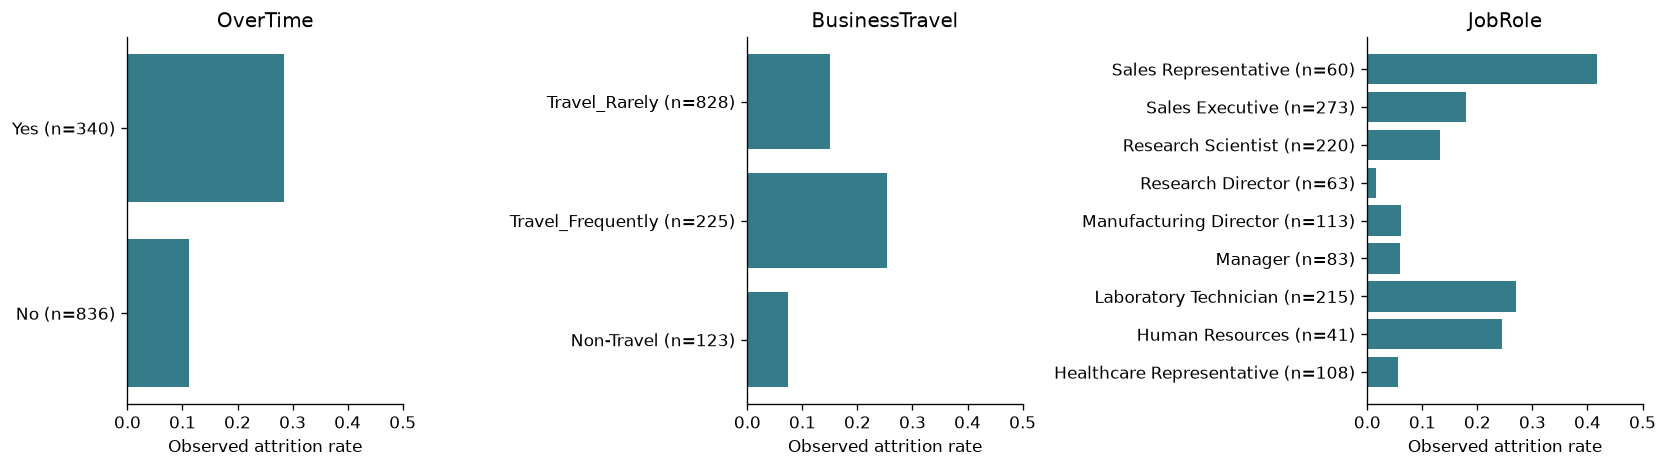

Training overtime groups: No: 11.1% observed attrition (n=836); Yes: 28.5% observed attrition (n=340). These are associations, not treatment effects.

In [2]:
display(tables['category_target_rates'])
display(Image(filename=str(FIGURES_DIR / 'categorical_attrition.png')))
overtime = tables['category_target_rates'].query("feature == 'OverTime'")
display(Markdown('Training overtime groups: ' + '; '.join(
    f'{row.value}: {row.attrition_rate:.1%} observed attrition (n={row.count})'
    for row in overtime.itertuples()) + '. These are associations, not treatment effects.'))

## Numeric distributions and feature-versus-target analysis

Density histograms normalize the unequal class sizes. The tables cover all numeric predictors, including daily/hourly/monthly rates, satisfaction ratings, training, salary hikes, and tenure variables.

,count,mean,std,min,25%,50%,75%,max
Age,1176.0,36.998299,9.178142,18.0,30.00,36.0,43.00,60.0
DailyRate,1176.0,803.991497,401.339423,103.0,467.75,799.5,1157.00,1499.0
DistanceFromHome,1176.0,9.357993,8.179803,1.0,2.00,7.0,14.00,29.0
Education,1176.0,2.906463,1.027996,1.0,2.00,3.0,4.00,5.0
EnvironmentSatisfaction,1176.0,2.716837,1.088707,1.0,2.00,3.0,4.00,4.0
HourlyRate,1176.0,65.500000,20.373324,30.0,48.00,66.0,83.00,100.0
JobInvolvement,1176.0,2.737245,0.703673,1.0,2.00,3.0,3.00,4.0
JobLevel,1176.0,2.076531,1.091987,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1176.0,2.719388,1.110644,1.0,2.00,3.0,4.00,4.0
MonthlyIncome,1176.0,6544.024660,4653.743955,1009.0,2948.00,5004.5,8420.50,19973.0


Attrition                                   0             1
Age                      mean       37.744422     33.126316
                         median     36.000000     31.000000
DailyRate                mean      816.564909    738.742105
                         median    817.500000    668.000000
DistanceFromHome         mean        9.046653     10.973684
                         median      7.000000      9.000000
Education                mean        2.919878      2.836842
                         median      3.000000      3.000000
EnvironmentSatisfaction  mean        2.770791      2.436842
                         median      3.000000      3.000000
HourlyRate               mean       65.673428     64.600000
                         median     66.000000     64.000000
JobInvolvement           mean        2.775862      2.536842
                         median      3.000000      3.000000
JobLevel                 mean        2.156187      1.663158
                         median      2.000000      1.000000
JobSatisfaction          mean        2.769777      2.457895
                         median      3.000000      3.000000
MonthlyIncome            mean     6871.638945   4843.878947
                         median   5237.500000   3373.000000
MonthlyRate              mean    14321.476673  14747.084211
                         median  14294.000000  14691.500000
NumCompaniesWorked       mean        2.639959      2.968421
                         median      2.000000      1.000000
PercentSalaryHike        mean       15.254564     15.163158
                         median     14.000000     14.000000
PerformanceRating        mean        3.156187      3.163158
                         median      3.000000      3.000000
RelationshipSatisfaction mean        2.759635      2.631579
                         median      3.000000      3.000000
StockOptionLevel         mean        0.843813      0.515789
                         median      1.000000      0.000000
TotalWorkingYears        mean       12.002028      8.057895
                         median     10.000000      7.000000
TrainingTimesLastYear    mean        2.781947      2.647368
                         median      3.000000      2.000000
WorkLifeBalance          mean        2.782961      2.626316
                         median      3.000000      3.000000
YearsAtCompany           mean        7.464503      4.900000
                         median      6.000000      3.000000
YearsInCurrentRole       mean        4.492901      2.873684
                         median      3.000000      2.000000
YearsSinceLastPromotion  mean        2.243408      1.868421
                         median      1.000000      1.000000
YearsWithCurrManager     mean        4.460446      2.826316
                         median      3.000000      2.000000

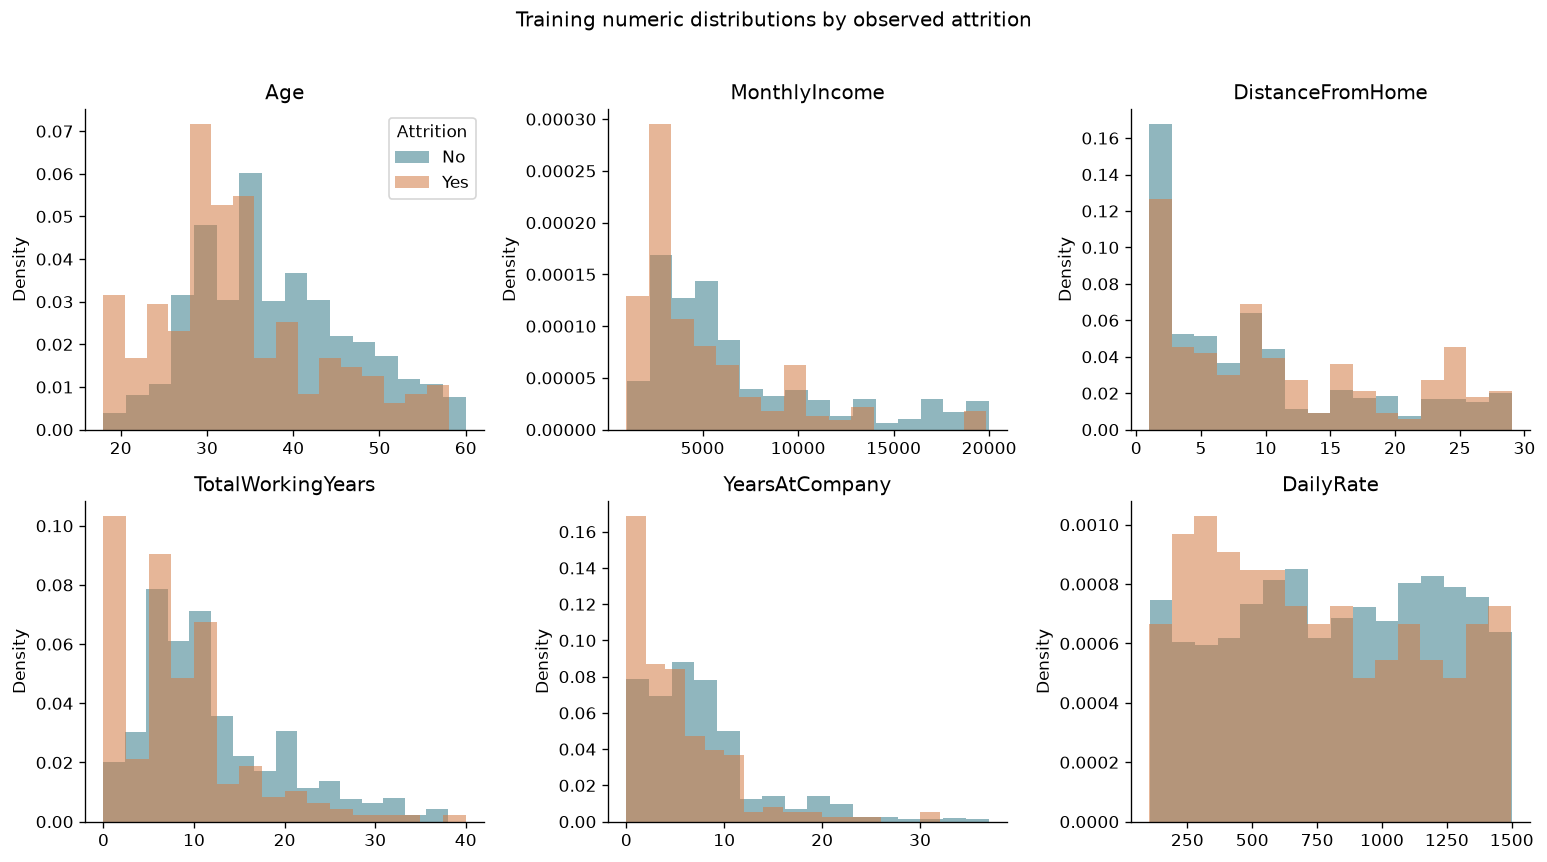

In [3]:
display(tables['summary_statistics'])
display(tables['numeric_by_target'].T)
display(Image(filename=str(FIGURES_DIR / 'numeric_distributions.png')))

## Outlier inspection

An IQR flag is an inspection prompt, not evidence of an error. High income may reflect seniority, and bounded ordinal scales are not continuous measurements. We retain observations and use regularization and shallow trees rather than arbitrary trimming.

In [4]:
display(tables['iqr_outlier_counts'].sort_values('outlier_count', ascending=False))
display(X_train.nlargest(8, 'MonthlyIncome')[['MonthlyIncome', 'JobLevel', 'JobRole', 'TotalWorkingYears']])

,outlier_count
PerformanceRating,185
TrainingTimesLastYear,174
MonthlyIncome,86
YearsSinceLastPromotion,85
StockOptionLevel,66
TotalWorkingYears,52
YearsAtCompany,52
NumCompaniesWorked,36
YearsInCurrentRole,16
YearsWithCurrManager,10


,MonthlyIncome,JobLevel,JobRole,TotalWorkingYears
746,19973,5,Research Director,21
851,19943,5,Manager,28
165,19926,5,Manager,21
568,19859,5,Manager,24
918,19847,5,Manager,31
749,19845,5,Manager,33
1242,19833,5,Manager,21
1331,19665,5,Research Director,29


## Related compensation and tenure measurements

Examine correlation before removing information. JobLevel and MonthlyIncome describe related aspects of seniority; career tenure fields also overlap. The modeling notebook reports a prespecified reduced-feature CV experiment.

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.024387,0.026070,0.200322,0.019456,0.035842,0.046711,0.526493,0.004963,0.511433,...,0.025537,0.037142,0.032187,0.694507,-0.038122,-0.032473,0.313363,0.218484,0.211487,0.203502
DailyRate,0.024387,1.000000,0.001514,-0.003387,0.020719,0.027642,0.039663,0.020215,0.023370,0.023467,...,-0.005306,0.006753,0.046350,0.021565,-0.009423,-0.040173,-0.025003,0.023581,-0.033547,-0.020495
DistanceFromHome,0.026070,0.001514,1.000000,0.043053,-0.010683,0.026303,0.027889,0.021989,-0.027529,0.000454,...,0.027642,0.006785,0.034329,0.017810,-0.048123,-0.012456,0.012665,0.020539,0.009547,0.012793
Education,0.200322,-0.003387,0.043053,1.000000,-0.054864,0.046894,0.042469,0.093569,-0.020773,0.083713,...,-0.006127,0.016969,0.021524,0.141366,-0.013429,-0.008829,0.059782,0.048809,0.055387,0.077941
EnvironmentSatisfaction,0.019456,0.020719,-0.010683,-0.054864,1.000000,-0.055195,0.002780,-0.008243,-0.005943,-0.015123,...,-0.037803,0.000769,0.004937,-0.014983,-0.022309,0.034071,0.001632,0.012706,0.003131,-0.004515
HourlyRate,0.035842,0.027642,0.026303,0.046894,-0.055195,1.000000,0.032205,-0.016258,-0.070259,-0.001685,...,-0.007053,0.003938,0.045636,0.014985,-0.025471,-0.000378,-0.024944,-0.020691,-0.017494,-0.017337
JobInvolvement,0.046711,0.039663,0.027889,0.042469,0.002780,0.032205,1.000000,0.007363,-0.012751,0.001080,...,-0.051102,0.035970,0.020538,-0.001128,-0.034752,-0.026754,-0.039642,-0.010345,-0.034797,0.010415
JobLevel,0.526493,0.020215,0.021989,0.093569,-0.008243,-0.016258,0.007363,1.000000,0.000179,0.947008,...,0.001801,-0.005380,-0.000160,0.785244,0.000361,0.036695,0.526719,0.373405,0.332935,0.362996
JobSatisfaction,0.004963,0.023370,-0.027529,-0.020773,-0.005943,-0.070259,-0.012751,0.000179,1.000000,-0.007220,...,0.025062,-0.004333,0.018998,-0.014107,-0.019600,-0.018113,-0.016045,-0.025261,-0.034716,-0.035936
MonthlyIncome,0.511433,0.023467,0.000454,0.083713,-0.015123,-0.001685,0.001080,0.947008,-0.007220,1.000000,...,0.002283,0.002028,-0.017485,0.774830,-0.003819,0.028111,0.504502,0.346182,0.322003,0.326894


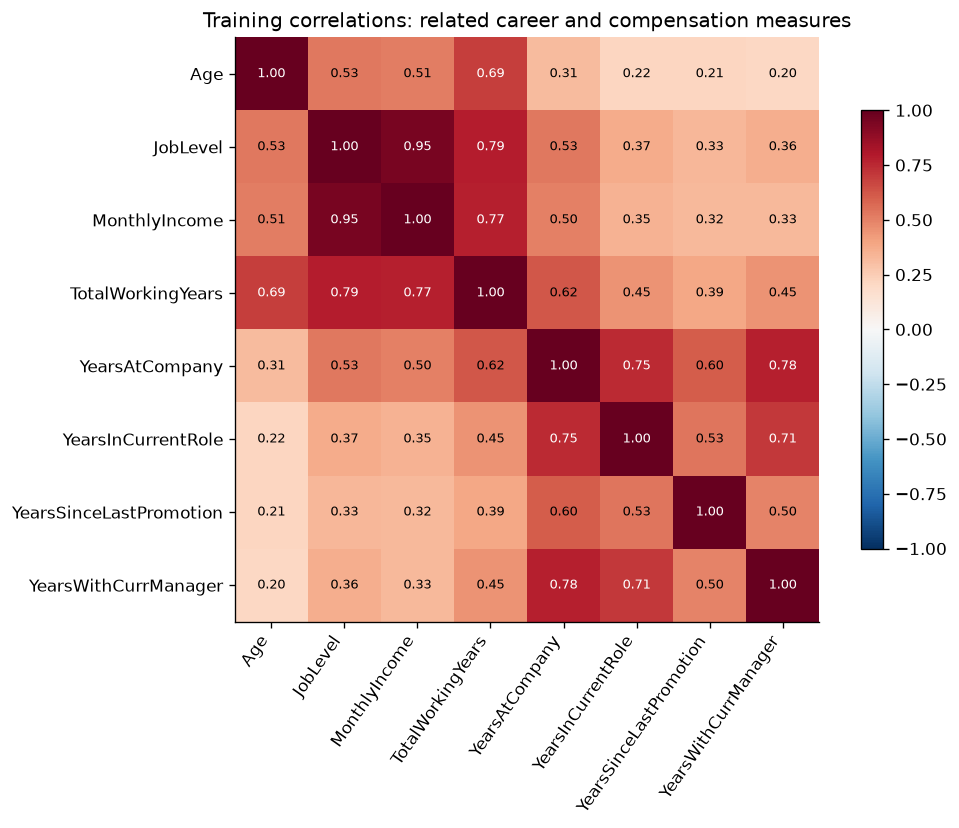

JobLevel–MonthlyIncome training correlation: **0.947**. Correlation can make individual importance estimates unstable; it does not alone justify dropping either field.

In [5]:
display(tables['numeric_correlations'])
display(Image(filename=str(FIGURES_DIR / 'numeric_correlations.png')))
corr = tables['numeric_correlations']
display(Markdown(f'JobLevel–MonthlyIncome training correlation: **{corr.loc["JobLevel", "MonthlyIncome"]:.3f}**. ''Correlation can make individual importance estimates unstable; it does not alone justify dropping either field.'))

## Key Findings

Group rates, normalized distributions, and summary tables reveal predictive associations and unequal sample sizes. Outlier flags and related career variables warrant investigation, not automatic deletion. Age, Gender, and MaritalStatus require a responsible-use review.

## Next Steps

Keep preprocessing inside cross-validation and compare models using average precision, recall, and F1. Preserve the reserved holdout until the operating policy is fixed.